# Data og modeller

For å koble data til modeller skal vi bruke python-bibliotekene pandas og numpy


Datasettet kan lastes ned her:

- [Last ned norway_load_2025.csv](data/norway_load_2025.csv)



In [2]:
#| hide-cell
import pandas as pd

df = pd.read_csv("../data/load_data.csv", sep=",")
df

,Time(Local),Production,Consumption
0,01.01.2026 00:00:00 +01:00,"18448,59","16662,95"
1,01.01.2026 01:00:00 +01:00,"18693,66","14953,24"
2,01.01.2026 02:00:00 +01:00,"18639,68","14298,07"
3,01.01.2026 03:00:00 +01:00,"18502,66","13254,81"
4,01.01.2026 04:00:00 +01:00,"18458,45","12678,51"
...,...,...,...
3354,20.05.2026 19:00:00 +02:00,"13799,35","19331,51"
3355,20.05.2026 20:00:00 +02:00,"13857,89","20096,14"
3356,20.05.2026 21:00:00 +02:00,"13768,33","19944,19"
3357,20.05.2026 22:00:00 +02:00,"13646,36","19368,15"


In [3]:
#| hide-cell
print(df.columns)

Index(['Time(Local)', 'Production', 'Consumption'], dtype='object')


In [4]:
#| hide-cell
df = pd.read_csv("../data/load_data.csv", parse_dates=["Time(Local)"])
#df = df.set_index("Time(Local)")

In [5]:
#| hide-cell
print(df["Time(Local)"].head())
print(type(df["Time(Local)"].iloc[0]))

0    01.01.2026 00:00:00 +01:00
1    01.01.2026 01:00:00 +01:00
2    01.01.2026 02:00:00 +01:00
3    01.01.2026 03:00:00 +01:00
4    01.01.2026 04:00:00 +01:00
Name: Time(Local), dtype: object
<class 'str'>


In [6]:
#| hide-cell
print(df.columns)

Index(['Time(Local)', 'Production', 'Consumption'], dtype='object')


In [7]:
#| hide-cell
df.columns = df.columns.str.strip()

df["Time(Local)"] = pd.to_datetime(
    df["Time(Local)"],
    dayfirst=True,
    utc=True   # ✅ THIS solves your error
)

df = df.set_index("Time(Local)")
df = df.sort_index()

df = df.tz_convert("Europe/Oslo")


In [8]:
#| hide-cell
print(df.columns)

Index(['Production', 'Consumption'], dtype='object')


In [9]:
#| hide-cell
print(df.head())

                          Production Consumption
Time(Local)                                     
2026-01-01 00:00:00+01:00   18448,59    16662,95
2026-01-01 01:00:00+01:00   18693,66    14953,24
2026-01-01 02:00:00+01:00   18639,68    14298,07
2026-01-01 03:00:00+01:00   18502,66    13254,81
2026-01-01 04:00:00+01:00   18458,45    12678,51


Første linje i dataene 18448,59 er norsk format: , = desimaltegn

pandas har lest det som tekst

FIX (konverter til tall)

In [10]:
#| hide-cell
df["Consumption"] = df["Consumption"].str.replace(",", ".").astype(float)

In [11]:
#| hide-cell
print(df.dtypes)

Production      object
Consumption    float64
dtype: object


In [12]:
import numpy as np

# df: time-serie med load
# index = datetime

# Lag daglig matrise (hver dag = 24 verdier)
df['date'] = df.index.date
daily = df.groupby('date')['Consumption'].apply(list)
print('Daglige tidsserier:',daily)
# Fjern dager som ikke har 24 timer
daily = daily[daily.apply(len) == 24]
print(daily)
# Konverter til array
X = np.vstack(daily.values)
print(X)
# Gjennomsnittsdøgn
mean_profile = X.mean(axis=0)
print(mean_profile)
# Finn dag med minst avvik (minste norm)
distances = np.linalg.norm(X - mean_profile, axis=1)

# Velg mest representative dag
idx = np.argmin(distances)

rep_profile = X[idx]
rep_date = daily.index[idx]


print("Representativ dag:", rep_date)

Daglige tidsserier: date
2026-01-01    [16662.95, 14953.24, 14298.07, 13254.81, 12678...
2026-01-02    [14821.37, 13826.33, 12743.11, 12786.86, 12647...
2026-01-03    [22115.9, 21572.64, 20710.6, 20344.44, 19724.8...
2026-01-04    [23251.09, 22995.68, 22691.57, 22255.31, 21886...
2026-01-05    [24208.62, 23689.68, 23986.93, 23956.24, 24106...
                                    ...                        
2026-05-16    [16276.98, 14535.05, 13984.31, 13857.01, 13656...
2026-05-17    [14220.04, 12912.59, 12540.78, 12134.04, 11770...
2026-05-18    [15629.79, 14382.06, 14139.4, 14017.26, 14589....
2026-05-19    [17748.79, 17015.92, 16436.45, 15904.32, 15931...
2026-05-20    [14881.17, 14265.45, 13891.66, 13679.98, 13776...
Name: Consumption, Length: 140, dtype: object
date
2026-01-01    [16662.95, 14953.24, 14298.07, 13254.81, 12678...
2026-01-02    [14821.37, 13826.33, 12743.11, 12786.86, 12647...
2026-01-03    [22115.9, 21572.64, 20710.6, 20344.44, 19724.8...
2026-01-04    [23251.09, 229

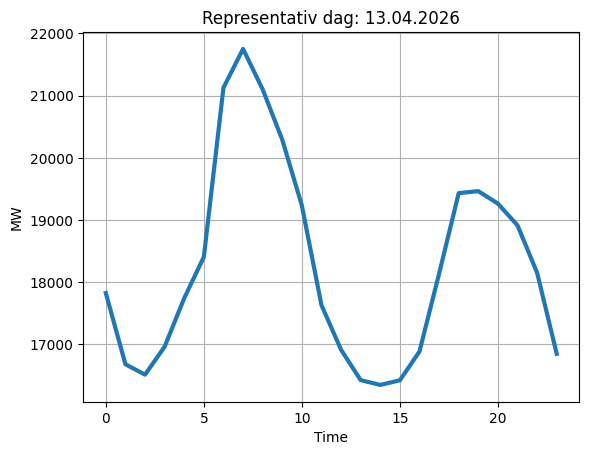

In [13]:

import matplotlib.pyplot as plt

t = np.arange(24)

plt.plot(t, rep_profile, linewidth=3)
plt.xlabel("Time")
plt.ylabel("MW")
plt.title(f"Representativ dag: {rep_date.strftime('%d.%m.%Y')}")
plt.grid(True)
plt.show()
